# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  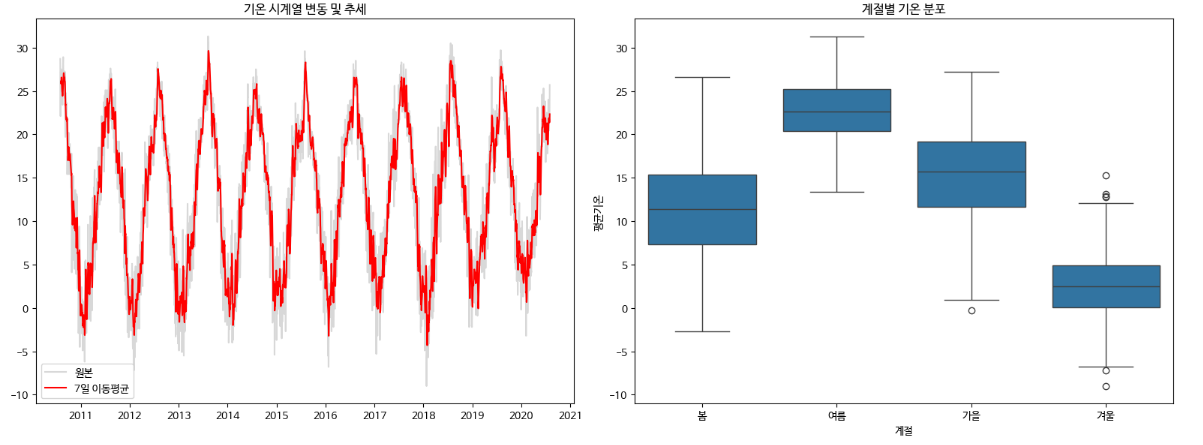

  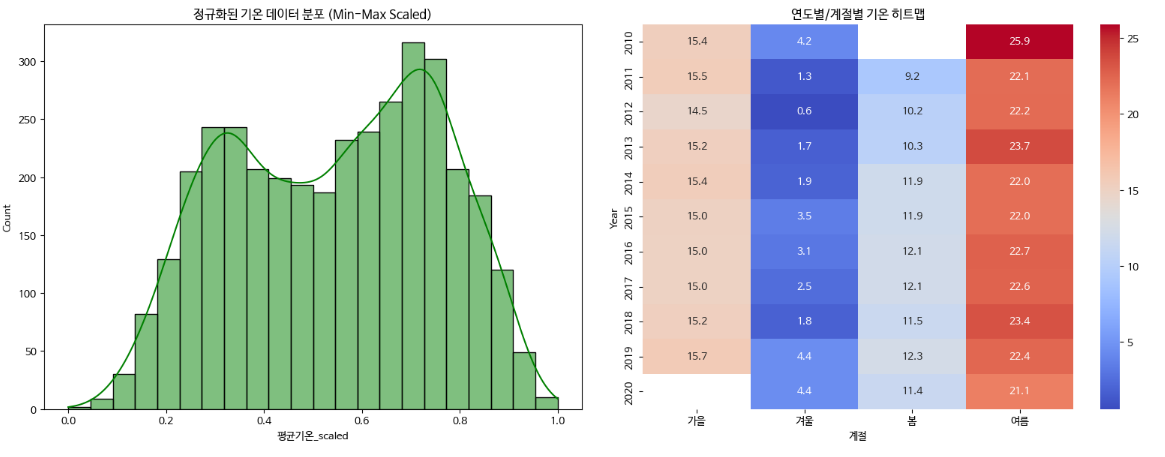



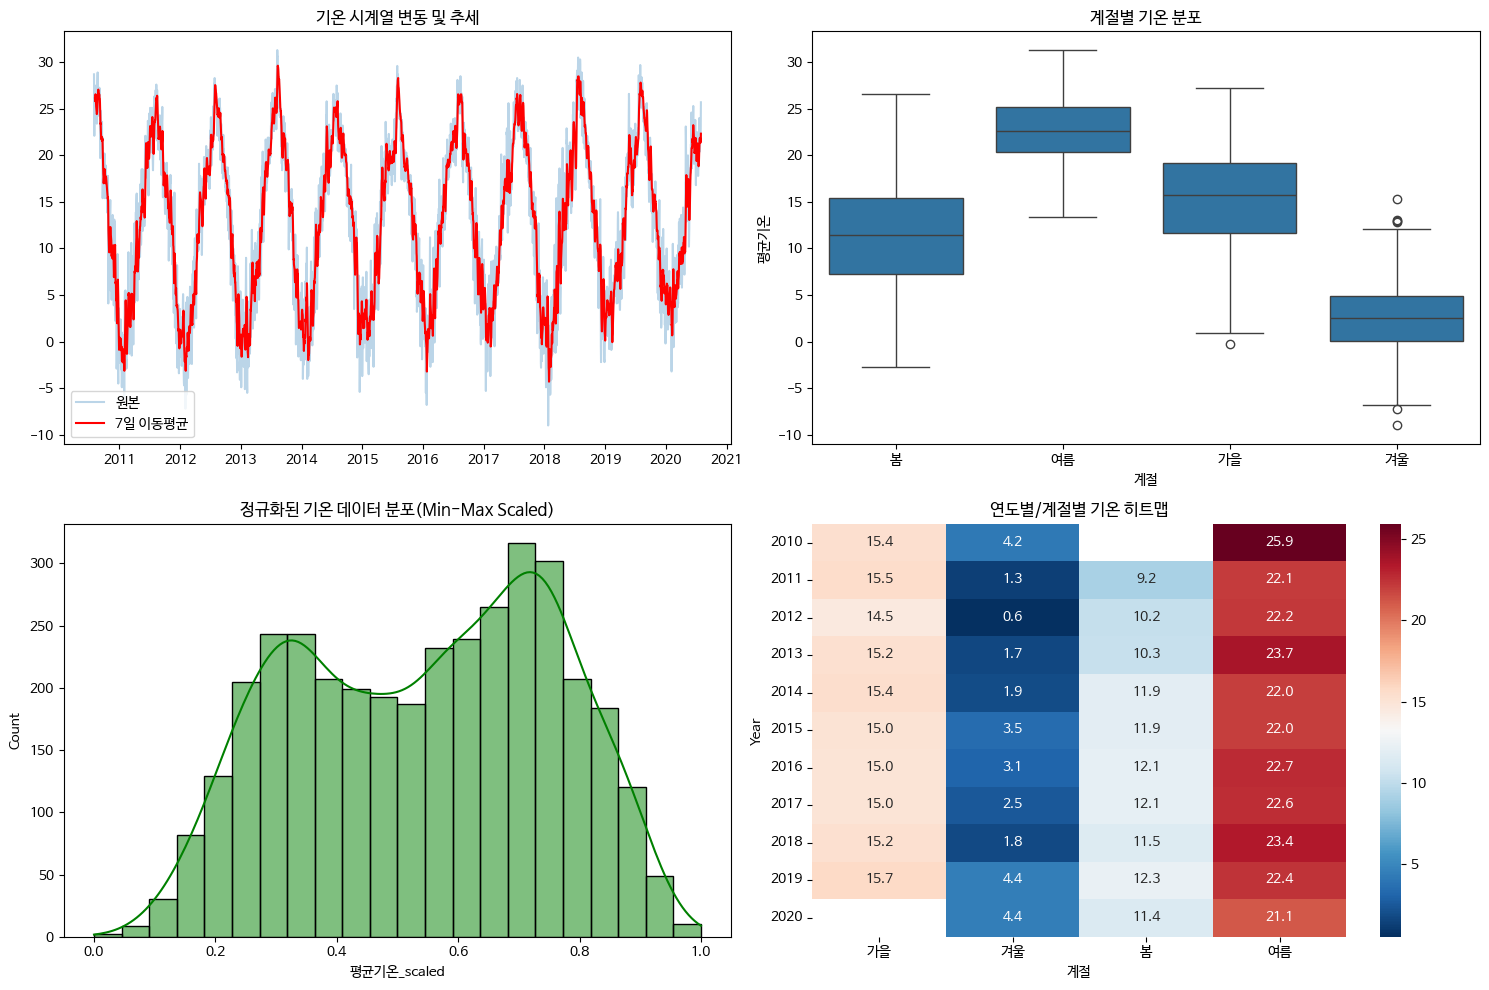

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    fm.fontManager.addfont(font_path)

    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False

def load_data(url):
  df = pd.read_csv(url, index_col=0, encoding='CP949')
  df.index = pd.to_datetime(df.index)
  return df

def preprocessing(df):
  df['7일_이동평균'] = df['평균기온'].rolling(window=7).mean()
  df['계절'] = (df.index.month % 12 // 3).map({0: '겨울', 1: '봄', 2: '여름', 3: '가을'})
  df['연도'] = df.index.year
  return df

def min_max_scaling(df, column):
  scaled_temp = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
  return scaled_temp

def create_summary(df):
  df_group = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()
  df_pivot = pd.pivot_table(df, index='연도', columns='계절', values='평균기온')
  return df_group, df_pivot

def visualization(df, pivot_df):
  plt.figure(figsize=(15, 10))

  plt.subplot(2,2,1)
  plt.plot(df.index, df['평균기온'], label='원본', alpha=0.3)
  plt.plot(df.index, df['7일_이동평균'], label='7일 이동평균', color='red')
  plt.title('기온 시계열 변동 및 추세')
  plt.legend(loc='lower left', fontsize=10)

  plt.subplot(2,2,2)
  sns.boxplot(data=df, x='계절', y='평균기온', order=['봄', '여름', '가을', '겨울'])
  plt.title('계절별 기온 분포')

  plt.subplot(2,2,3)
  sns.histplot(df['평균기온_scaled'], bins=22, color='green', kde=True)
  plt.title('정규화된 기온 데이터 분포(Min-Max Scaled)')

  plt.subplot(2,2,4)
  sns.heatmap(pivot_df, annot=True, cmap='RdBu_r', fmt='.1f')
  plt.title('연도별/계절별 기온 히트맵')
  plt.ylabel('Year')

  plt.tight_layout()
  plt.show()

def save_to_excel(df, df_group, df_pivot, filename):
  with pd.ExcelWriter(filename) as writer:
    df.to_excel(writer, sheet_name='전처리_데이터')
    df_group.to_excel(writer, sheet_name='계절별_통계')
    df_pivot.to_excel(writer, sheet_name='연도별_피벗')

def main():
  setup_korean_font()

  url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'

  weather = load_data(url)

  weather = preprocessing(weather)

  weather['평균기온_scaled'] = min_max_scaling(weather, '평균기온')

  df_group, df_pivot = create_summary(weather)

  visualization(weather, df_pivot)

  save_to_excel(weather, df_group, df_pivot, 'weather_analysis_report.xlsx')

main()